In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("drsaeedmohsen/ucihar-dataset")

print("Path to dataset files:", path)

100%|██████████| 59.7M/59.7M [00:03<00:00, 19.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/drsaeedmohsen/ucihar-dataset/versions/1


In [2]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

1/
    UCI-HAR Dataset/
        test/
            Inertial Signals/
        train/
            Inertial Signals/


In [3]:
import numpy as np
import pandas as pd

def load_file(filepath):
    # Load a single file as a numpy array
    df = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return df.values

def load_group(filenames, prefix=''):
    # Load a list of files into a 3D numpy array
    loaded = []
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # Stack across the third dimension (Features)
    return np.dstack(loaded)

# Define the 9 files we need
filenames = [
    'body_acc_x_train.txt', 'body_acc_y_train.txt', 'body_acc_z_train.txt',
    'body_gyro_x_train.txt', 'body_gyro_y_train.txt', 'body_gyro_z_train.txt',
    'total_acc_x_train.txt', 'total_acc_y_train.txt', 'total_acc_z_train.txt'
]

# Note: You'll need to append the correct sub-folder path to 'path'
# e.g., train_path = os.path.join(path, 'train/Inertial Signals/')

In [4]:
import os

# 1. Let's find where the 'train' folder actually is
def find_data_dir(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None

data_dir = find_data_dir(path)

if data_dir:
    print(f"Found data directory at: {data_dir}")
else:
    print("Could not find the dataset folders. Please check if the download finished.")

# 2. Now run the loading code again using this 'data_dir'
# (The load_signals and load_y functions remain the same)

Found data directory at: /root/.cache/kagglehub/datasets/drsaeedmohsen/ucihar-dataset/versions/1/UCI-HAR Dataset


In [5]:
import os
import numpy as np

# Updated with the HYPHEN as seen in your output
data_dir = os.path.join(path, 'UCI-HAR Dataset')

def load_signals(data_path, group, filenames):
    signals = []
    for name in filenames:
        # Constructing the path carefully
        filepath = os.path.join(data_path, group, 'Inertial Signals', f'{name}_{group}.txt')
        with open(filepath, 'r') as f:
            data = [row.split() for row in f]
            signals.append(np.array(data, dtype=float))
    return np.transpose(np.array(signals), (1, 2, 0))

def load_y(data_path, group):
    filepath = os.path.join(data_path, group, f'y_{group}.txt')
    with open(filepath, 'r') as f:
        y = [row.split() for row in f]
    return np.array(y, dtype=int)

signal_names = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

# Now it should work perfectly!
X_train = load_signals(data_dir, 'train', signal_names)
y_train = load_y(data_dir, 'train')
X_test = load_signals(data_dir, 'test', signal_names)
y_test = load_y(data_dir, 'test')

print(f"✅ Success! X_train shape: {X_train.shape}")

✅ Success! X_train shape: (7352, 128, 9)


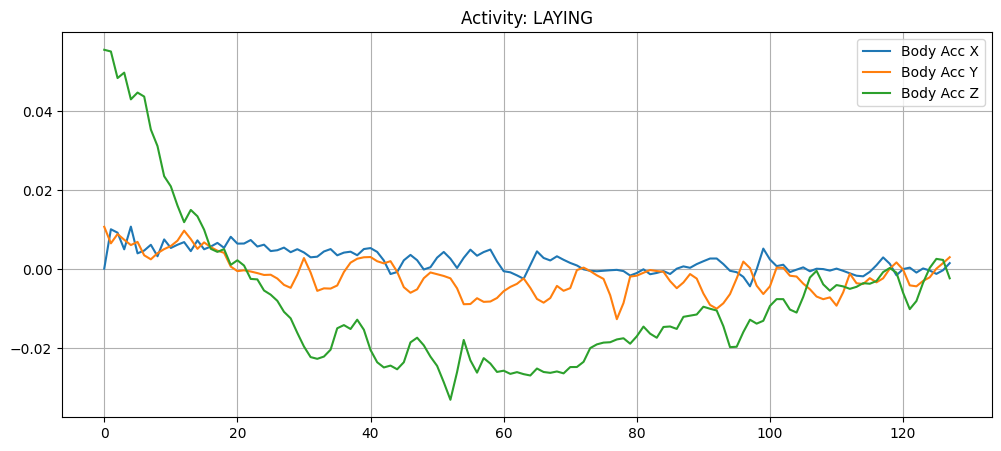

In [6]:
# Define the mapping of activity IDs to human-readable names
activities = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

# Now try the plotting code again!
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(X_train[0, :, 0], label='Body Acc X')
plt.plot(X_train[0, :, 1], label='Body Acc Y')
plt.plot(X_train[0, :, 2], label='Body Acc Z')

# This will now work because 'activities' is defined
plt.title(f"Activity: {activities[y_train[600][0]]}")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from tensorflow.keras.utils import to_categorical

# Convert labels 1-6 to 0-5 and then to One-Hot format
y_train_encoded = to_categorical(y_train - 1, num_classes=6)
y_test_encoded = to_categorical(y_test - 1, num_classes=6)

print(f"Target shape: {y_train_encoded.shape}") # Should be (7352, 6)

Target shape: (7352, 6)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input

In [9]:
model=Sequential([
    Input(shape=(128,9)),

    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),

    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
                  ])

In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy' ,metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,310 (1.20 MB)

 Trainable params: 314,310 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history=model.fit(X_train, y_train_encoded,epochs=50,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 77s 761ms/step - accuracy: 0.5621 - loss: 1.0207 - val_accuracy: 0.6757 - val_loss: 0.8129
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 707ms/step - accuracy: 0.7747 - loss: 0.5535 - val_accuracy: 0.7070 - val_loss: 0.7093
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 699ms/step - accuracy: 0.7978 - loss: 0.5324 - val_accuracy: 0.8443 - val_loss: 0.5659
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 696ms/step - accuracy: 0.8988 - loss: 0.2912 - val_accuracy: 0.8749 - val_loss: 0.5447
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 694ms/step - accuracy: 0.9214 - loss: 0.2102 - val_accuracy: 0.8919 - val_loss: 0.4579
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 694ms/step - accuracy: 0.9221 - loss: 0.2212 - val_accuracy: 0.8858 - val_loss: 0.4478
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 64s 691ms/step - accuracy: 0.9459 - loss: 0.1389 - val_accuracy: 0.8933 - val_loss: 0.4735
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 746ms/step - accuracy: 0.9553 - loss: 0.1195 - val_accu

93/93 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step


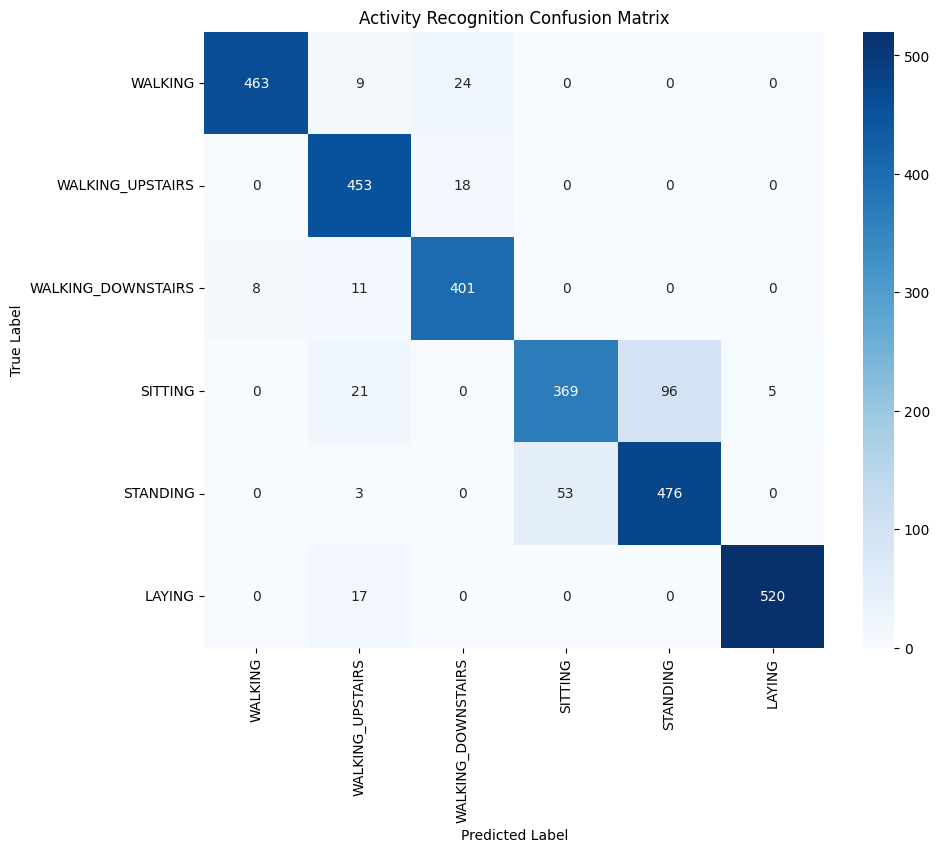

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the model's predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class IDs
y_true = np.argmax(y_test_encoded, axis=1)

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plot it beautifully
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activities.values(),
            yticklabels=activities.values())
plt.title('Activity Recognition Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [13]:
from tensorflow.keras.layers import GRU

model_GRU = Sequential([
    Input(shape=(128, 9)),
    Bidirectional(GRU(128, return_sequences=True)), # Using GRU instead of LSTM
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

In [14]:
model_GRU.compile(optimizer='adam', loss='categorical_crossentropy' ,metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 942,932 (3.60 MB)

 Trainable params: 314,310 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 628,622 (2.40 MB)

In [15]:
hist=model_GRU.fit(X_train, y_train_encoded,epochs=50,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 740ms/step - accuracy: 0.4897 - loss: 1.1813 - val_accuracy: 0.6186 - val_loss: 1.0545
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 66s 715ms/step - accuracy: 0.6880 - loss: 0.7511 - val_accuracy: 0.8124 - val_loss: 0.5812
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 712ms/step - accuracy: 0.8726 - loss: 0.3664 - val_accuracy: 0.8695 - val_loss: 0.3751
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 84s 732ms/step - accuracy: 0.9157 - loss: 0.2382 - val_accuracy: 0.8858 - val_loss: 0.2955
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 80s 714ms/step - accuracy: 0.9352 - loss: 0.1788 - val_accuracy: 0.9245 - val_loss: 0.2493
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 67s 732ms/step - accuracy: 0.9480 - loss: 0.1314 - val_accuracy: 0.9205 - val_loss: 0.2291
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 728ms/step - accuracy: 0.9519 - loss: 0.1209 - val_accuracy: 0.9007 - val_loss: 0.3024
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 65s 703ms/step - accuracy: 0.9514 - loss: 0.1229 - val_accu

93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step


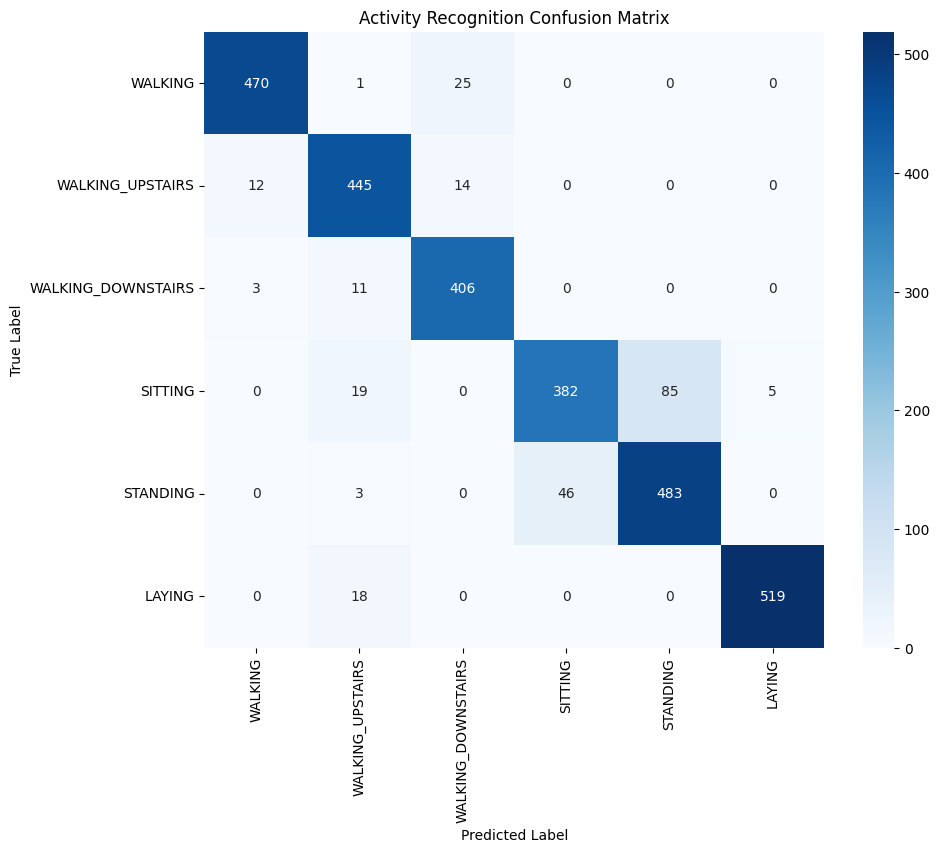

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the model's predictions on the test set
y_pred = model_GRU.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class IDs
y_true = np.argmax(y_test_encoded, axis=1)

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Plot it beautifully
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activities.values(),
            yticklabels=activities.values())
plt.title('Activity Recognition Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step


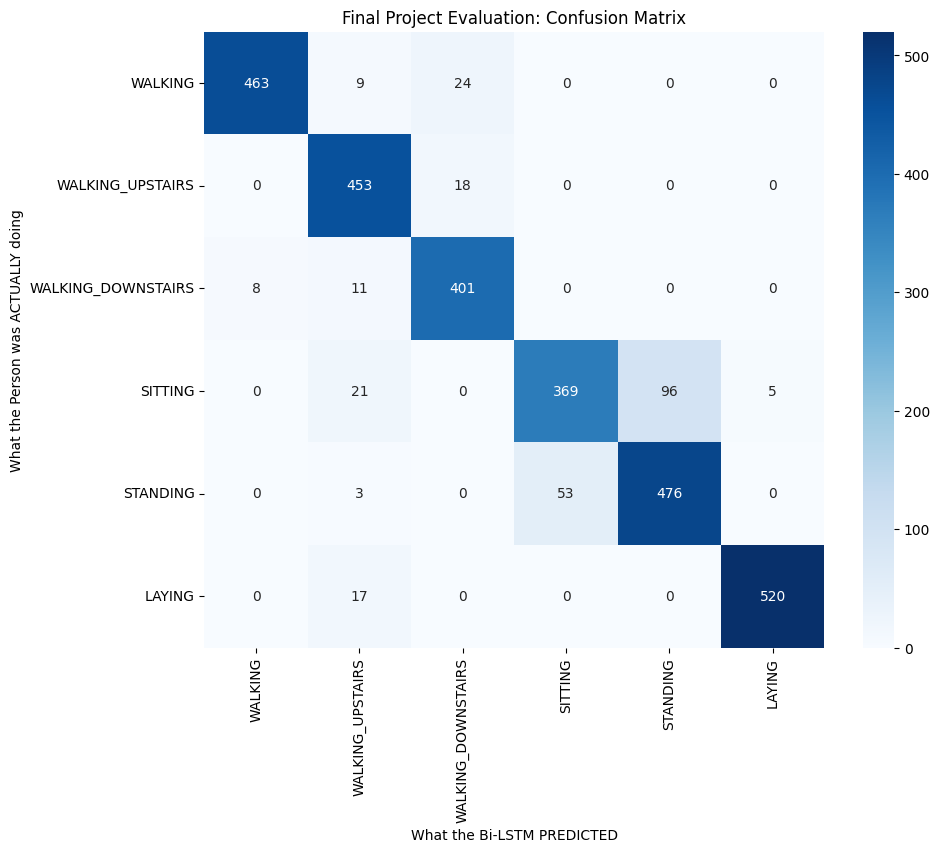

                    precision    recall  f1-score   support

           WALKING       0.98      0.93      0.96       496
  WALKING_UPSTAIRS       0.88      0.96      0.92       471
WALKING_DOWNSTAIRS       0.91      0.95      0.93       420
           SITTING       0.87      0.75      0.81       491
          STANDING       0.83      0.89      0.86       532
            LAYING       0.99      0.97      0.98       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions on the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class IDs (0-5)
y_true = np.argmax(y_test_encoded, axis=1) # Convert one-hot truth to class IDs (0-5)

# 2. Map the 0-5 indices back to human names for the plot
class_labels = [activities[i+1] for i in range(6)]

# 3. Create the matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Project Evaluation: Confusion Matrix')
plt.ylabel('What the Person was ACTUALLY doing')
plt.xlabel('What the Bi-LSTM PREDICTED')
plt.show()

# 5. Print the detailed stats
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step


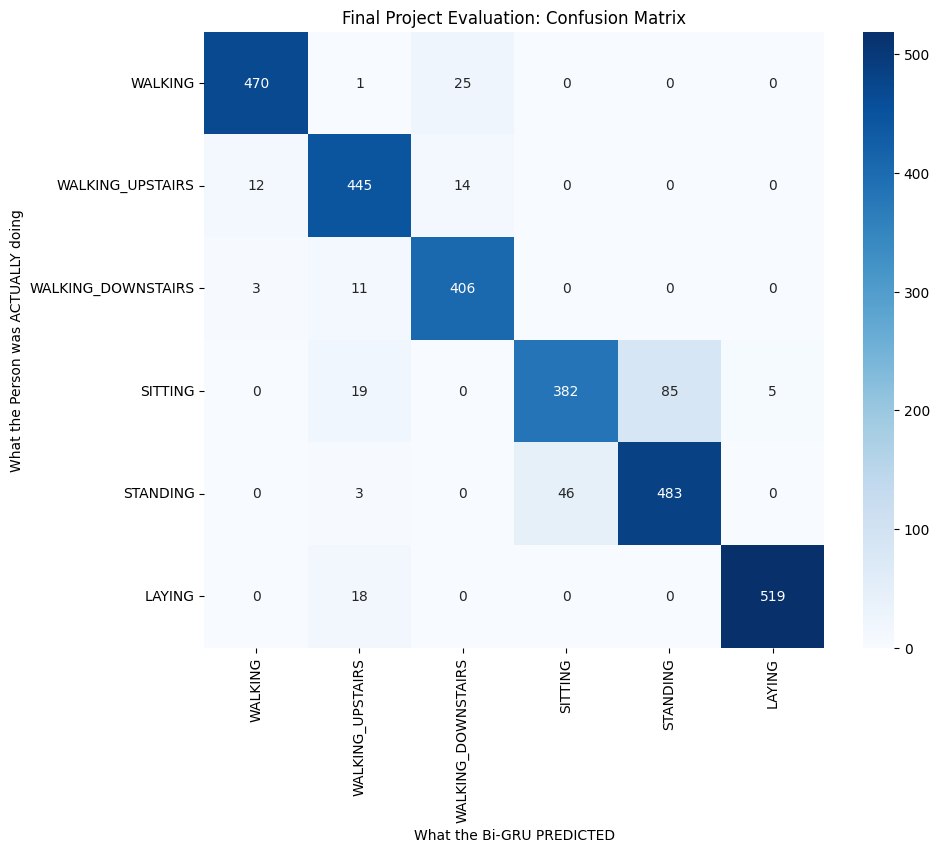

                    precision    recall  f1-score   support

           WALKING       0.97      0.95      0.96       496
  WALKING_UPSTAIRS       0.90      0.94      0.92       471
WALKING_DOWNSTAIRS       0.91      0.97      0.94       420
           SITTING       0.89      0.78      0.83       491
          STANDING       0.85      0.91      0.88       532
            LAYING       0.99      0.97      0.98       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions on the test set
y_pred = model_GRU.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class IDs (0-5)
y_true = np.argmax(y_test_encoded, axis=1) # Convert one-hot truth to class IDs (0-5)

# 2. Map the 0-5 indices back to human names for the plot
class_labels = [activities[i+1] for i in range(6)]

# 3. Create the matrix
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Final Project Evaluation: Confusion Matrix')
plt.ylabel('What the Person was ACTUALLY doing')
plt.xlabel('What the Bi-GRU PREDICTED')
plt.show()

# 5. Print the detailed stats
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

In [19]:
model_GRU.save('best_BI_GRU.h5')